# ZOO: Zeroth Order Optimization — L2 Black-Box Attack
PyTorch implementation of the [ZOO attack](https://arxiv.org/abs/1708.03999).  
Generates adversarial examples by estimating gradients via coordinate-wise finite differences — no model gradients needed.

Available solvers: `adam`, `newton`, `sgd`, `signsgd`, `lion`

## 1. Imports

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
from torchvision import transforms, datasets
import math
import time
import os
import sys
import json
from PIL import Image
from skimage.metrics import peak_signal_noise_ratio as calc_psnr
from skimage.metrics import structural_similarity as calc_ssim
from setup_mnist_model import MNIST
from setup_cifar10_model import CIFAR10
from setup_imagenet_model import VGG16Wrapper, imagenet_transform, get_imagenet_labels


## 2. Coordinate Descent Solvers (GPU-native)
All solvers are pure PyTorch — no Numba, no CPU↔GPU copies. Gradient is estimated via symmetric finite differences on GPU tensors. All state (`mt`, `vt`, `adam_epoch`, `modifier_up/down`) lives on the device throughout.

In [39]:
# All solvers operate entirely on GPU tensors — no CPU round-trips.
# Signature: (losses, indice, mt, vt, adam_epoch, real_modifier, up, down, step_size, beta1, beta2, proj)
#   losses       : 1-D GPU float tensor, shape (2*batch_size+1,)  — [cur, +d0, -d0, +d1, -d1, ...]
#   indice       : 1-D GPU long tensor,  shape (batch_size,)       — pixel indices being updated
#   mt, vt       : 1-D GPU float32 tensors, shape (var_len,)       — momentum buffers
#   adam_epoch   : 1-D GPU float32 tensor, shape (var_len,)        — per-coord step counter
#   real_modifier: GPU float32 tensor, shape (1, C, H, W)          — perturbation (modified in-place)
#   up, down     : 1-D GPU float32 tensors, shape (var_len,)       — projection bounds

def coordinate_ADAM(losses, indice, mt, vt, adam_epoch, real_modifier, up, down, step_size, beta1, beta2, proj):
  g = ((losses[1::2] - losses[2::2]) / 0.0002).float()  # cast to float32 to match state tensors
  mt[indice] = beta1 * mt[indice] + (1 - beta1) * g
  vt[indice] = beta2 * vt[indice] + (1 - beta2) * g * g
  epoch = adam_epoch[indice]
  corr = torch.sqrt(1 - beta2 ** epoch) / (1 - beta1 ** epoch)
  m = real_modifier.view(-1)
  m[indice] = m[indice] - step_size * corr * mt[indice] / (torch.sqrt(vt[indice]) + 1e-8)
  if proj:
    m[indice] = torch.clamp(m[indice], down[indice], up[indice])
  adam_epoch[indice] += 1


def coordinate_Newton(losses, indice, mt, vt, adam_epoch, real_modifier, up, down, step_size, beta1, beta2, proj):
  cur_loss = losses[0]
  g    = ((losses[1::2] - losses[2::2]) / 0.0002).float()
  hess = ((losses[1::2] - 2 * cur_loss + losses[2::2]) / (0.0001 ** 2)).float()
  hess = torch.where(hess < 0, torch.ones_like(hess), hess)  # negative hess → 1.0
  hess = torch.clamp(hess, min=0.1)                           # hess < 0.1 → 0.1
  m = real_modifier.view(-1)
  m[indice] = m[indice] - step_size * g / hess
  if proj:
    m[indice] = torch.clamp(m[indice], down[indice], up[indice])


def coordinate_SGD(losses, indice, mt, vt, adam_epoch, real_modifier, up, down, step_size, beta1, beta2, proj):
  """Vanilla gradient descent — no momentum."""
  g = ((losses[1::2] - losses[2::2]) / 0.0002).float()
  m = real_modifier.view(-1)
  m[indice] = m[indice] - step_size * g
  if proj:
    m[indice] = torch.clamp(m[indice], down[indice], up[indice])

def coordinate_SGDSign(losses, indice, mt, vt, adam_epoch, real_modifier, up, down, step_size, beta1, beta2, proj):
  """SGDSign — step is step_size * sign(g), no momentum."""
  g = ((losses[1::2] - losses[2::2]) / 0.0002).float()
  m = real_modifier.view(-1)
  m[indice] = m[indice] - step_size * torch.sign(g)
  if proj:
    m[indice] = torch.clamp(m[indice], down[indice], up[indice])

def coordinate_Signum(losses, indice, mt, vt, adam_epoch, real_modifier, up, down, step_size, beta1, beta2, proj):
  """Signum — step is step_size * sign(m), where m is an EMA of gradients."""
  g = ((losses[1::2] - losses[2::2]) / 0.0002).float()
  mt[indice] = beta1 * mt[indice] + (1 - beta1) * g
  m = real_modifier.view(-1)
  m[indice] = m[indice] - step_size * torch.sign(mt[indice])
  if proj:
    m[indice] = torch.clamp(m[indice], down[indice], up[indice])


def coordinate_Lion(losses, indice, mt, vt, adam_epoch, real_modifier, up, down, step_size, beta1, beta2, proj):
  """Lion optimizer (EvoLved Sign Momentum) — arxiv.org/abs/2302.06675
  u = sign(beta1*m + (1-beta1)*g)  ->  theta -= lr*u  ->  m = beta2*m + (1-beta2)*g
  """
  g = ((losses[1::2] - losses[2::2]) / 0.0002).float()
  update = torch.sign(beta1 * mt[indice] + (1 - beta1) * g)
  m = real_modifier.view(-1)
  m[indice] = m[indice] - step_size * update
  if proj:
    m[indice] = torch.clamp(m[indice], down[indice], up[indice])
  mt[indice] = beta2 * mt[indice] + (1 - beta2) * g          # momentum updated AFTER the step

def coordinate_AdaHessian(losses, indice, mt, vt, adam_epoch, real_modifier, up, down, step_size, beta1, beta2, proj):
  """AdaHessian (Yao et al., 2021) — arxiv.org/abs/2006.00719
  Second moment tracks EMA of h², where h is the FD Hessian diagonal.
  Negative-curvature coordinates fall back to h=1 (same as Newton) to avoid
  freezing in saddle regions. vt is initialised effectively at hess_floor² to
  avoid the cold-start blow-up that occurs when vt≈0 at the first iterations.

  mt : EMA of gradient               (first moment)
  vt : EMA of h²                     (second moment — Hessian-based, not gradient-based)
  Update: theta -= lr * m_hat / (sqrt(v_hat) + eps)
  """
  HESS_FLOOR = 0.1   # match Newton's floor so saddle regions behave consistently
  cur_loss = losses[0]
  g    = ((losses[1::2] - losses[2::2]) / 0.0002).float()
  hess = ((losses[1::2] - 2 * cur_loss + losses[2::2]) / (0.0001 ** 2)).float()
  # Negative curvature → fall back to 1.0, same policy as Newton
  hess = torch.where(hess < 0, torch.ones_like(hess), hess)
  hess = torch.clamp(hess, min=HESS_FLOOR)

  mt[indice] = beta1 * mt[indice] + (1 - beta1) * g
  vt[indice] = beta2 * vt[indice] + (1 - beta2) * hess * hess   # EMA of h²

  epoch = adam_epoch[indice]
  corr  = torch.sqrt(1 - beta2 ** epoch) / (1 - beta1 ** epoch)

  m = real_modifier.view(-1)
  m[indice] = m[indice] - step_size * corr * mt[indice] / (torch.sqrt(vt[indice]) + 1e-8)
  if proj:
    m[indice] = torch.clamp(m[indice], down[indice], up[indice])
  adam_epoch[indice] += 1

## 3. Loss Function
Computes the ZOO objective: $\|x' - x\|_2^2 + c \cdot f(x')$  
where $f(x')$ penalises correct classification (targeted or untargeted).

In [9]:
def loss_run(input, target, model, modifier, use_tanh, use_log, targeted, confidence, const, device='cpu'):
  if use_tanh:
    pert_out = torch.tanh(input + modifier) / 2
  else:
    pert_out = input + modifier

  output = model(pert_out)
  if use_log:
    output = F.softmax(output, -1)

  if use_tanh:
    loss1 = torch.sum(torch.square(pert_out - torch.tanh(input) / 2), dim=(1, 2, 3))
  else:
    loss1 = torch.sum(torch.square(pert_out - input), dim=(1, 2, 3))

  real = torch.sum(target * output, -1)
  other = torch.max((1 - target) * output - (target * 10000), -1)[0]

  if use_log:
    real = torch.log(real + 1e-30)
    other = torch.log(other + 1e-30)

  confidence = torch.tensor(confidence).type(torch.float64).to(device)

  if targeted:
    loss2 = torch.max(other - real, confidence)
  else:
    loss2 = torch.max(real - other, confidence)

  loss2 = const * loss2
  loss = loss1 + loss2

  # losses/l2/loss2 stay on GPU (consumed by solvers); scores+pert_images go to CPU for output
  return loss.detach(), loss1.detach(), loss2.detach(), output.detach().cpu().numpy(), pert_out.detach().cpu().numpy()

def l2_attack(input, target, model, targeted, use_log, use_tanh, solver, device='cpu', reset_adam_after_found=True,abort_early=True,
              batch_size=128,max_iter=1000,const=0.01,confidence=0.0,early_stop_iters=100, binary_search_steps=9,
              step_size=0.01,adam_beta1=0.9,adam_beta2=0.999):

  early_stop_iters = early_stop_iters if early_stop_iters != 0 else max_iter // 10

  input = torch.from_numpy(input).to(device)
  target = torch.from_numpy(target).to(device)

  var_len = input.view(-1).size()[0]
  # All state tensors live on device — no CPU↔GPU copies during the attack loop
  modifier_up   = torch.zeros(var_len, dtype=torch.float32, device=device)
  modifier_down = torch.zeros(var_len, dtype=torch.float32, device=device)
  real_modifier = torch.zeros(input.size(), dtype=torch.float32, device=device)
  mt            = torch.zeros(var_len, dtype=torch.float32, device=device)
  vt            = torch.zeros(var_len, dtype=torch.float32, device=device)
  adam_epoch    = torch.ones(var_len,  dtype=torch.float32, device=device)

  upper_bound=1e10
  lower_bound=0.0
  out_best_attack=input.clone().detach().cpu().numpy()
  out_best_const=const
  out_bestl2=1e10
  out_bestscore=-1


  if use_tanh:
    input = torch.atanh(input*1.99999)

  if not use_tanh:
    flat = input.clone().detach().view(-1)
    modifier_up   =  0.5 - flat
    modifier_down = -0.5 - flat

  def compare(x,y):
    if not isinstance(x, (float, int, np.int64)):
      if targeted:
        x[y] -= confidence
      else:
        x[y] += confidence
      x = np.argmax(x)
    if targeted:
      return x == y
    else:
      return x != y

  for step in range(binary_search_steps):
    bestl2 = 1e10
    prev=1e6
    bestscore=-1
    last_loss2=1.0
    # reset solver state
    mt.zero_()
    vt.zero_()
    adam_epoch.fill_(1)
    stage=0

    for iter in range(max_iter):
      if (iter+1)%100 == 0:
        loss, l2, loss2, _ , __ = loss_run(input,target,model,real_modifier,use_tanh,use_log,targeted,confidence,const,device)
        print("[STATS][L2] iter = {}, loss = {:.5f}, loss1 = {:.5f}, loss2 = {:.5f}".format(iter+1, loss[0].item(), l2[0].item(), loss2[0].item()))
        sys.stdout.flush()

      # Sample random coordinates entirely on GPU — no numpy, no CPU transfer
      indice = torch.randperm(var_len, device=device)[:batch_size]
      # Build (2*batch_size+1) perturbed copies of real_modifier on GPU
      var = real_modifier.expand(batch_size * 2 + 1, *input.shape[1:]).clone()
      flat_var = var.view(batch_size * 2 + 1, -1)
      pos_idx = torch.arange(batch_size, device=device) * 2 + 1
      neg_idx = torch.arange(batch_size, device=device) * 2 + 2
      flat_var[pos_idx, indice] += 0.0001
      flat_var[neg_idx, indice] -= 0.0001

      losses, l2s, losses2, scores, pert_images = loss_run(input,target,model,var,use_tanh,use_log,targeted,confidence,const,device)

      # Solver updates real_modifier in-place — everything stays on GPU
      if solver=="adam":
        coordinate_ADAM(losses,indice,mt,vt,adam_epoch,real_modifier,modifier_up,modifier_down,step_size,adam_beta1,adam_beta2,proj=not use_tanh)
      if solver=="newton":
        coordinate_Newton(losses,indice,mt,vt,adam_epoch,real_modifier,modifier_up,modifier_down,step_size,adam_beta1,adam_beta2,proj=not use_tanh)
      if solver=="sgd":
        coordinate_SGD(losses,indice,mt,vt,adam_epoch,real_modifier,modifier_up,modifier_down,step_size,adam_beta1,adam_beta2,proj=not use_tanh)
      if solver=="sgdsign":
        coordinate_SGDSign(losses,indice,mt,vt,adam_epoch,real_modifier,modifier_up,modifier_down,step_size,adam_beta1,adam_beta2,proj=not use_tanh)
      if solver=="signum":
        coordinate_Signum(losses,indice,mt,vt,adam_epoch,real_modifier,modifier_up,modifier_down,step_size,adam_beta1,adam_beta2,proj=not use_tanh)
      if solver=="lion":
        coordinate_Lion(losses,indice,mt,vt,adam_epoch,real_modifier,modifier_up,modifier_down,step_size,adam_beta1,adam_beta2,proj=not use_tanh)
      if solver=="adahessian":
        coordinate_AdaHessian(losses,indice,mt,vt,adam_epoch,real_modifier,modifier_up,modifier_down,step_size,adam_beta1,adam_beta2,proj=not use_tanh)

      loss2_val = losses2[0].item()
      if loss2_val==0.0 and last_loss2!=0.0 and stage==0:
        if reset_adam_after_found:
          mt.zero_()
          vt.zero_()
          adam_epoch.fill_(1)
        stage=1
      last_loss2=loss2_val

      loss_val = losses[0].item()
      if abort_early and (iter+1) % early_stop_iters == 0:
        if loss_val > prev*.9999:
            print("Early stopping because there is no improvement")
            break
        prev = loss_val

      l2_val = l2s[0].item()
      target_label = np.argmax(target.detach().cpu().numpy(),-1)
      if l2_val < bestl2 and compare(scores[0], target_label):
        bestl2 = l2_val
        bestscore = np.argmax(scores[0])

      if l2_val < out_bestl2 and compare(scores[0], target_label):
        if out_bestl2 == 1e10:
          print("[STATS][L3](First valid attack found!) iter = {}, loss = {:.5f}, loss1 = {:.5f}, loss2 = {:.5f}".format(iter+1, loss_val, l2_val, loss2_val))
          sys.stdout.flush()
        out_bestl2 = l2_val
        out_bestscore = np.argmax(scores[0])
        out_best_attack = pert_images[0]
        out_best_const = const

    if compare(bestscore, np.argmax(target.detach().cpu().numpy(),-1)) and bestscore != -1:
      print('old constant: ', const)
      upper_bound = min(upper_bound,const)
      if upper_bound < 1e9:
          const = (lower_bound + upper_bound)/2
      print('new constant: ', const)
    else:
      print('old constant: ', const)
      lower_bound = max(lower_bound,const)
      if upper_bound < 1e9:
          const = (lower_bound + upper_bound)/2
      else:
          const *= 10
      print('new constant: ', const)

  return out_best_attack, out_bestscore

## 4. L2 Attack Core
Runs binary search over the constant $c$, with coordinate descent in each step.

In [ ]:
def generate_data(test_loader, targeted, samples, start, num_label=10):
  inputs = []
  targets = []
  cnt = 0
  for i, data in enumerate(test_loader):
    if cnt < samples:
      if i > start:
        data, label = data[0], data[1]
        if targeted:
          for j in range(num_label):
            if j == label.item():
              continue
            inputs.append(data[0].numpy())
            targets.append(np.eye(num_label)[j])
        else:
          inputs.append(data[0].numpy())
          targets.append(np.eye(num_label)[label.item()])
        cnt += 1
    else:
      break
  return np.array(inputs), np.array(targets)


def run_attack(inputs, targets, model, targeted, use_log, use_tanh, solver, device, step_size=0.01):
  r = []
  print('go up to', len(inputs))
  for i in range(len(inputs)):
    print('tick', i + 1)
    adv, score = l2_attack(np.expand_dims(inputs[i], 0), np.expand_dims(targets[i], 0),
                           model, targeted, use_log, use_tanh, solver, device=device,
                           step_size=step_size)
    r.append(adv)
  return np.array(r)


## 5. Data Generation & Attack Runner

In [ ]:
def generate_data(test_loader, targeted, samples, start, num_label=10):
  inputs = []
  targets = []
  cnt = 0
  for i, data in enumerate(test_loader):
    if cnt < samples:
      if i > start:
        data, label = data[0], data[1]
        if targeted:
          for j in range(num_label):
            if j == label.item():
              continue
            inputs.append(data[0].numpy())
            targets.append(np.eye(num_label)[j])
        else:
          inputs.append(data[0].numpy())
          targets.append(np.eye(num_label)[label.item()])
        cnt += 1
    else:
      break
  return np.array(inputs), np.array(targets)


def run_attack(inputs, targets, model, targeted, use_log, use_tanh, solver, device, step_size):
  r = []
  print('go up to', len(inputs))
  for i in range(len(inputs)):
    print('tick', i + 1)
    adv, score = l2_attack(np.expand_dims(inputs[i], 0), np.expand_dims(targets[i], 0),
                           model, targeted, use_log, use_tanh, solver, device=device, step_size=step_size)
    r.append(adv)
  return np.array(r)


## 6. Configuration
Edit the settings below to switch between MNIST/CIFAR-10, targeted/untargeted, and solver.

In [ ]:
np.random.seed(42)
torch.manual_seed(42)

use_cuda = True
device = torch.device("cuda" if (use_cuda and torch.cuda.is_available()) else "cpu")
print("Using device:", device)

# --- Dataset ---
# Uncomment one block:

# MNIST
# dataset_name = "mnist"
# transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (1.0,))])
# test_set = datasets.MNIST(root='./data', train=False, transform=transform, download=True)

# CIFAR-10
dataset_name = "cifar10"
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (1.0,))])
test_set = datasets.CIFAR10(root='./data', train=False, transform=transform, download=True)

# ImageNet (using a small subset for testing)
# dataset_name = "imagenet"
# test_set = datasets.ImageFolder(root='./data/imagenet_subset', transform=imagenet_transform())


test_loader = torch.utils.data.DataLoader(test_set, batch_size=1, shuffle=True)

# --- Model ---
# model = MNIST().to(device)
# model.load_state_dict(torch.load('./models/mnist_model.pt', map_location=device, weights_only=False))

model = CIFAR10().to(device)
model.load_state_dict(torch.load('./models/cifar10_model.pt', map_location=device, weights_only=False))
model.eval()

# model = VGG16Wrapper().to(device)
# model.load_state_dict(torch.load('./models/imagenet_vgg16.pt', map_location=device, weights_only=False))
# model.eval()


# --- Attack settings ---
use_log    = True
use_tanh   = True
targeted   = False
solver     = "adahessian"   # "adam" | "newton" | "sgd" | "sgdsign" | "signum" | "lion" | "adahessian"
samples    = 10
start      = 6

# ── Per-optimizer learning rates ─────────────────────────────────────────
ADAM_LR       = 0.01
NEWTON_LR     = 0.01
SGD_LR        = 0.01
SGDSIGN_LR    = 0.01
SIGNUM_LR     = 0.001
LION_LR       = 0.01
ADAHESSIAN_LR = 0.01

lr_map = {
    "adam":       ADAM_LR,
    "newton":     NEWTON_LR,
    "sgd":        SGD_LR,
    "sgdsign":    SGDSIGN_LR,
    "signum":     SIGNUM_LR,
    "lion":       LION_LR,
    "adahessian": ADAHESSIAN_LR,
}
step_size = lr_map[solver]

Using device: cuda


## 6.5 Exclude the misclassified examples

In [44]:
data, label = generate_data(test_loader,targeted=False,samples=len(test_loader),start=6)
pred = model(torch.from_numpy(data).to(device))
pred = torch.argmax(pred,dim=-1).cpu().numpy()
label = np.argmax(label,axis=-1)
acc = (pred==label).sum()/len(pred)
print("Model accuracy on original samples: ", acc*100.0, "%")
# per class classification accuracy
print("labels: ", label)
for i in range(10):
    idx = label==i
    acc = (pred[idx]==label[idx]).sum()/idx.sum()
    print("Class {} accuracy: {:.2f}%".format(i, acc*100.0))

# exclude the missclassifed samples from the attack evaluation
data = data[pred==label]
label = label[pred==label]
print("Number of correctly classified samples: ", len(data))
test_loader = torch.utils.data.DataLoader(torch.utils.data.TensorDataset(torch.from_numpy(data), torch.from_numpy(label)), batch_size=1, shuffle=False)

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/dropout.py:176: UserWarning: dropout2d: Received a 2-D input to dropout2d, which is deprecated and will result in an error in a future release. To retain the behavior and silence this warning, please use dropout instead. Note that dropout2d exists to provide channel-wise dropout on inputs with 2 spatial dimensions, a channel dimension, and an optional batch dimension (i.e. 3D or 4D inputs).
  return F.dropout2d(input, self.p, self.training, self.inplace)


Model accuracy on original samples:  77.5142599819874 %
labels:  [3 5 8 ... 6 3 4]
Class 0 accuracy: 80.00%
Class 1 accuracy: 87.89%
Class 2 accuracy: 64.39%
Class 3 accuracy: 61.00%
Class 4 accuracy: 76.60%
Class 5 accuracy: 65.97%
Class 6 accuracy: 82.10%
Class 7 accuracy: 83.98%
Class 8 accuracy: 86.80%
Class 9 accuracy: 86.39%
Number of correctly classified samples:  7746


## 7. Run the Attack

In [45]:
inputs, targets = generate_data(test_loader, targeted, samples=samples, start=start)

timestart = time.time()
adv = run_attack(inputs, targets, model, targeted, use_log, use_tanh, solver, device, step_size=step_size)
timeend = time.time()

print("Took", (timeend - timestart) / 60.0, "mins to run", len(inputs), "samples.")

go up to 10
tick 1
[STATS][L2] iter = 100, loss = 0.25334, loss1 = 0.00028, loss2 = 0.25305
[STATS][L2] iter = 200, loss = 0.25144, loss1 = 0.00048, loss2 = 0.25097
[STATS][L2] iter = 300, loss = 0.25009, loss1 = 0.00062, loss2 = 0.24947
[STATS][L2] iter = 400, loss = 0.24881, loss1 = 0.00078, loss2 = 0.24803
[STATS][L2] iter = 500, loss = 0.24765, loss1 = 0.00094, loss2 = 0.24672
[STATS][L2] iter = 600, loss = 0.24649, loss1 = 0.00112, loss2 = 0.24537
[STATS][L2] iter = 700, loss = 0.24542, loss1 = 0.00130, loss2 = 0.24413
[STATS][L2] iter = 800, loss = 0.24444, loss1 = 0.00149, loss2 = 0.24296
[STATS][L2] iter = 900, loss = 0.24351, loss1 = 0.00168, loss2 = 0.24183
[STATS][L2] iter = 1000, loss = 0.24257, loss1 = 0.00189, loss2 = 0.24068
old constant:  0.01
new constant:  0.1
[STATS][L2] iter = 100, loss = 2.08451, loss1 = 0.02701, loss2 = 2.05750
[STATS][L2] iter = 200, loss = 2.03462, loss1 = 0.03491, loss2 = 1.99971
[STATS][L2] iter = 300, loss = 2.01534, loss1 = 0.03828, loss2 = 

## 8. Results

In [46]:
if use_log:
  valid_class = np.argmax(F.softmax(model(torch.from_numpy(inputs).to(device)), -1).detach().cpu().numpy(), -1)
  adv_class   = np.argmax(F.softmax(model(torch.from_numpy(adv).to(device)), -1).detach().cpu().numpy(), -1)
else:
  valid_class = np.argmax(model(torch.from_numpy(inputs).to(device)).detach().cpu().numpy(), -1)
  adv_class   = np.argmax(model(torch.from_numpy(adv).to(device)).detach().cpu().numpy(), -1)

acc              = ((valid_class == adv_class).sum()) / len(inputs)
success_rate     = (1.0 - acc) * 100.0
# total change depends on input size (L2)
total_distortion = float(np.sum((adv - inputs) ** 2) ** 0.5)
elapsed_mins     = (timeend - timestart) / 60.0

print("Valid Classification:      ", valid_class)
print("Adversarial Classification:", adv_class)
print("Success Rate:              ", success_rate, "%")
print("Total distortion:          ", total_distortion)

# ── Output directory: <dataset>/<targeted|untargeted>/<solver>/ ──────────────
targeted_str = "targeted" if targeted else "untargeted"
out_dir = os.path.join(dataset_name, targeted_str, solver)
os.makedirs(out_dir, exist_ok=True)

# ── Save images and compute perceptual metrics ────────────────────────────────
# Inputs are normalised with Normalize((0.5,),(1.0,)) → pixel = value + 0.5
mse_list = []
mae_list = []
psnr_list = []
ssim_list = []

for i in range(len(inputs)):
  orig_np = np.clip(inputs[i].transpose(1, 2, 0) + 0.5, 0.0, 1.0)  # (H,W,C) in [0,1]
  adv_np  = np.clip(adv[i].transpose(1, 2, 0)   + 0.5, 0.0, 1.0)

  orig_uint8 = (orig_np * 255).astype(np.uint8)
  adv_uint8  = (adv_np  * 255).astype(np.uint8)

  if orig_uint8.shape[2] == 1:          # grayscale (MNIST)
    orig_img = Image.fromarray(orig_uint8[:, :, 0], mode="L")
    adv_img  = Image.fromarray(adv_uint8[:, :, 0],  mode="L")
  else:                                  # RGB (CIFAR-10)
    orig_img = Image.fromarray(orig_uint8, mode="RGB")
    adv_img  = Image.fromarray(adv_uint8,  mode="RGB")

  orig_img.save(os.path.join(out_dir, f"original_{i}.png"))
  adv_img.save(os.path.join(out_dir,  f"adversarial_{i}.png"))

  mse = float(np.sum((orig_np - adv_np)**2))
  mae = float(np.sum(np.abs(orig_np - adv_np)))
  psnr = float(calc_psnr(orig_np, adv_np, data_range=1.0))
  if orig_np.shape[2] == 1:
    ssim = float(calc_ssim(orig_np[:, :, 0], adv_np[:, :, 0], data_range=1.0))
  else:
    ssim = float(calc_ssim(orig_np, adv_np, data_range=1.0, channel_axis=2))

  mse_list.append(mse)
  mae_list.append(mae)
  psnr_list.append(psnr)
  ssim_list.append(ssim)

# ── Write results.json ────────────────────────────────────────────────────────
results = {
    "dataset":                    dataset_name,
    "targeted":                   targeted,
    "solver":                     solver,
    "num_samples":                len(inputs),
    "success_rate_pct":           success_rate,
    "total_distortion":           total_distortion,
    "time_mins":                  elapsed_mins,
    "valid_classification":       valid_class.tolist(),
    "adversarial_classification": adv_class.tolist(),
    "mse": {
        "mean:"       : float(np.mean(mse_list)),
        "per_sample":  mse_list
    },
    "mae": {
        "mean":       float(np.mean(mae_list)),
        "per_sample": mae_list
    },
    "psnr": {
        "mean":       float(np.mean(psnr_list)),
        "per_sample": psnr_list
    },
    "ssim": {
        "mean":       float(np.mean(ssim_list)),
        "per_sample": ssim_list
    }
}

results_path = os.path.join(out_dir, "results.json")
with open(results_path, "w") as f:
    json.dump(results, f, indent=2)
print(f"Results saved to {results_path}")


Valid Classification:       [8 6 6 9 3 0 9 2 3 9]
Adversarial Classification: [8 5 3 8 2 2 7 6 5 1]
Success Rate:               90.0 %
Total distortion:           1.0473103523254395
Results saved to cifar10/untargeted/adahessian/results.json


/tmp/ipykernel_715/2546004713.py:42: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  orig_img = Image.fromarray(orig_uint8, mode="RGB")
/tmp/ipykernel_715/2546004713.py:43: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  adv_img  = Image.fromarray(adv_uint8,  mode="RGB")


## 9. Visualisation

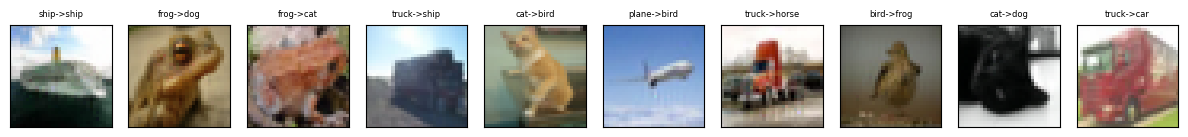

Saved: adahessian_untargeted_cifar10.png


<Figure size 640x480 with 0 Axes>

In [47]:
# --- CIFAR-10 visualisation ---
classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')
cnt = 0
plt.figure(figsize=(12, 12))
for i in range(len(adv)):
  cnt += 1
  plt.subplot(10, 10, cnt)
  plt.xticks([], [])
  plt.yticks([], [])
  plt.title("{}->{}".format(classes[valid_class[i]], classes[adv_class[i]]), fontsize=6)
  plt.imshow(((adv[i] + 0.5)).transpose(1, 2, 0))
plt.tight_layout()
plt.show()

# --- Save figure ---
fname = "{}_{}_cifar10.png".format(solver, "targeted" if targeted else "untargeted")
plt.savefig(fname)
print("Saved:", fname)

# --- MNIST visualisation (uncomment if using MNIST) ---
# plt.figure(figsize=(10,10))
# for i in range(len(adv)):
#   plt.subplot(10, 10, i+1)
#   plt.xticks([], []); plt.yticks([], [])
#   plt.title("{} -> {}".format(valid_class[i], adv_class[i]))
#   plt.imshow(adv[i].reshape(28, 28), cmap="gray")
# plt.tight_layout()
# plt.show()